# Neural Network from Scratch

**Level:** Foundational  
**Dataset:** MNIST — 70,000 handwritten digit images (0–9)  
**Goal:** Build a fully connected neural network using only NumPy — no frameworks, no autograd. Implement forward pass, backpropagation, and mini-batch gradient descent by hand.

By the end of this notebook you'll understand exactly what happens inside the 'black box' that Keras and PyTorch abstract away.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.datasets import mnist  # only used to download MNIST
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
np.random.seed(42)
IMG = '../images/'
print('Libraries loaded.')

Libraries loaded.


## 1. Load & Explore MNIST

**Why?** MNIST is the canonical benchmark for neural network classifiers — 28×28 grayscale images of handwritten digits. It is small enough to train quickly but complex enough to require real learning. Before building anything, we visualise the data to understand what we are asking the network to do.

In [2]:
(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

print(f'Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}')
print(f'Pixel range: [{X_train_raw.min()}, {X_train_raw.max()}]')
print(f'Classes: {np.unique(y_train)}')

       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/11490434 ━━━━━━━━━━━━━━━━━━━━ 55s 5us/step

   40960/11490434 ━━━━━━━━━━━━━━━━━━━━ 38s 3us/step

   49152/11490434 ━━━━━━━━━━━━━━━━━━━━ 49s 4us/step

   81920/11490434 ━━━━━━━━━━━━━━━━━━━━ 47s 4us/step

...

 9437184/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

10043392/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

10944512/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Train: (60000, 28, 28)  |  Test: (10000, 28, 28)
Pixel range: [0, 255]
Classes: [0 1 2 3 4 5 6 7 8 9]


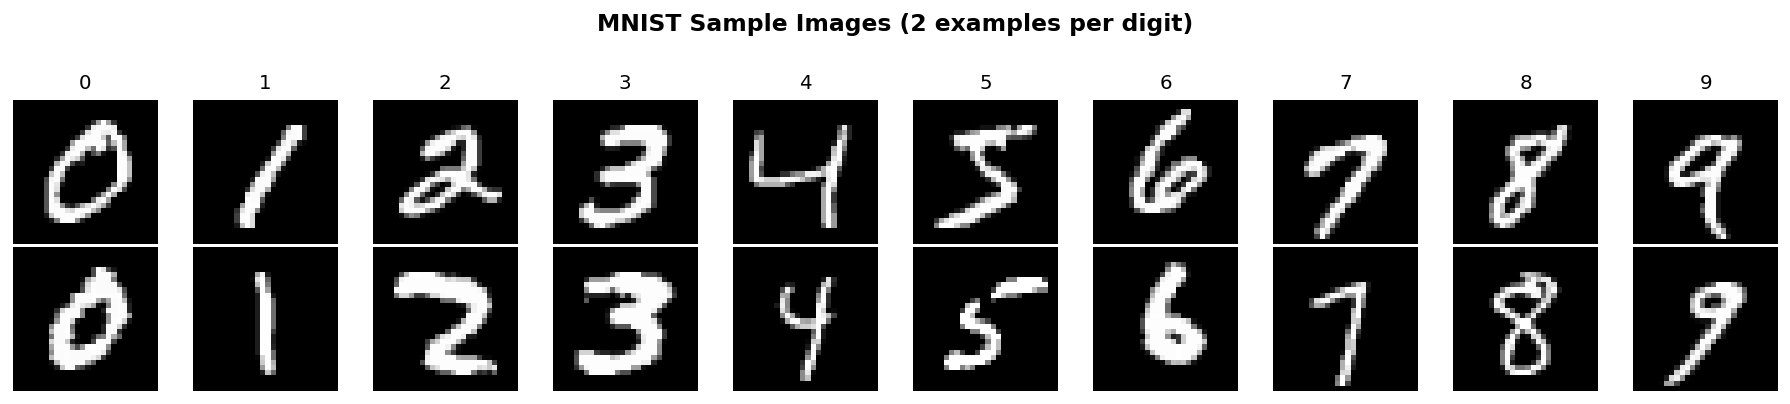

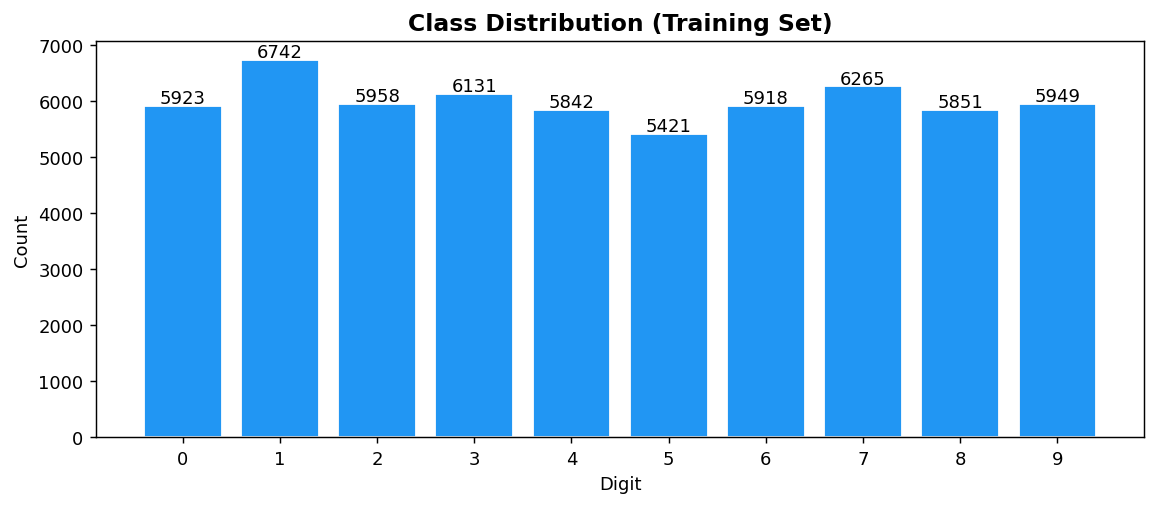

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    axes[0, digit].imshow(X_train_raw[idx], cmap='gray')
    axes[0, digit].set_title(str(digit), fontsize=11)
    axes[0, digit].axis('off')
    idx2 = np.where(y_train == digit)[0][3]
    axes[1, digit].imshow(X_train_raw[idx2], cmap='gray')
    axes[1, digit].axis('off')

plt.suptitle('MNIST Sample Images (2 examples per digit)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMG + '01_mnist_samples.png', bbox_inches='tight')
plt.show()

# Class distribution
fig, ax = plt.subplots(figsize=(9, 4))
unique, counts = np.unique(y_train, return_counts=True)
ax.bar(unique, counts, color='#2196F3', edgecolor='white')
for x, c in zip(unique, counts):
    ax.text(x, c + 50, str(c), ha='center', fontsize=10)
ax.set_title('Class Distribution (Training Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Digit')
ax.set_ylabel('Count')
ax.set_xticks(range(10))
plt.tight_layout()
plt.savefig(IMG + '01_class_distribution.png', bbox_inches='tight')
plt.show()

> **Key insight:** MNIST is well-balanced — ~6,000 samples per digit. The images are noisy and varied enough to require learning, not just memorisation. Notice the visual differences within the same class (different handwriting styles) — this is the intra-class variance the network must learn to ignore.

## 2. Preprocessing

**Why?** Neural networks are sensitive to input scale. Pixel values range from 0–255; we normalise to 0–1 so that no single feature dominates the gradient signal. We also flatten each 28×28 image to a 784-dimensional vector — a dense network treats every pixel as an independent input.

In [4]:
# Flatten and normalise
X_train = X_train_raw.reshape(60000, 784).astype(np.float32) / 255.0
X_test  = X_test_raw.reshape(10000, 784).astype(np.float32) / 255.0

# One-hot encode labels (needed for cross-entropy)
def one_hot(y, n_classes=10):
    ohe = np.zeros((len(y), n_classes))
    ohe[np.arange(len(y)), y] = 1
    return ohe

Y_train = one_hot(y_train)
Y_test  = one_hot(y_test)

print(f'X_train: {X_train.shape}  range [{X_train.min():.2f}, {X_train.max():.2f}]')
print(f'Y_train: {Y_train.shape}  example: {Y_train[0]}')

X_train: (60000, 784)  range [0.00, 1.00]
Y_train: (60000, 10)  example: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 3. Activation Functions

**Why?** Without non-linear activation functions, stacking layers is equivalent to a single linear transformation — the network could not learn curves, boundaries, or any non-linear pattern. We implement three:
- **ReLU** — fast, avoids vanishing gradients, used in hidden layers
- **Softmax** — converts raw scores to probabilities that sum to 1, used in output layer
- **Sigmoid** — squashes to (0,1), shown for comparison only

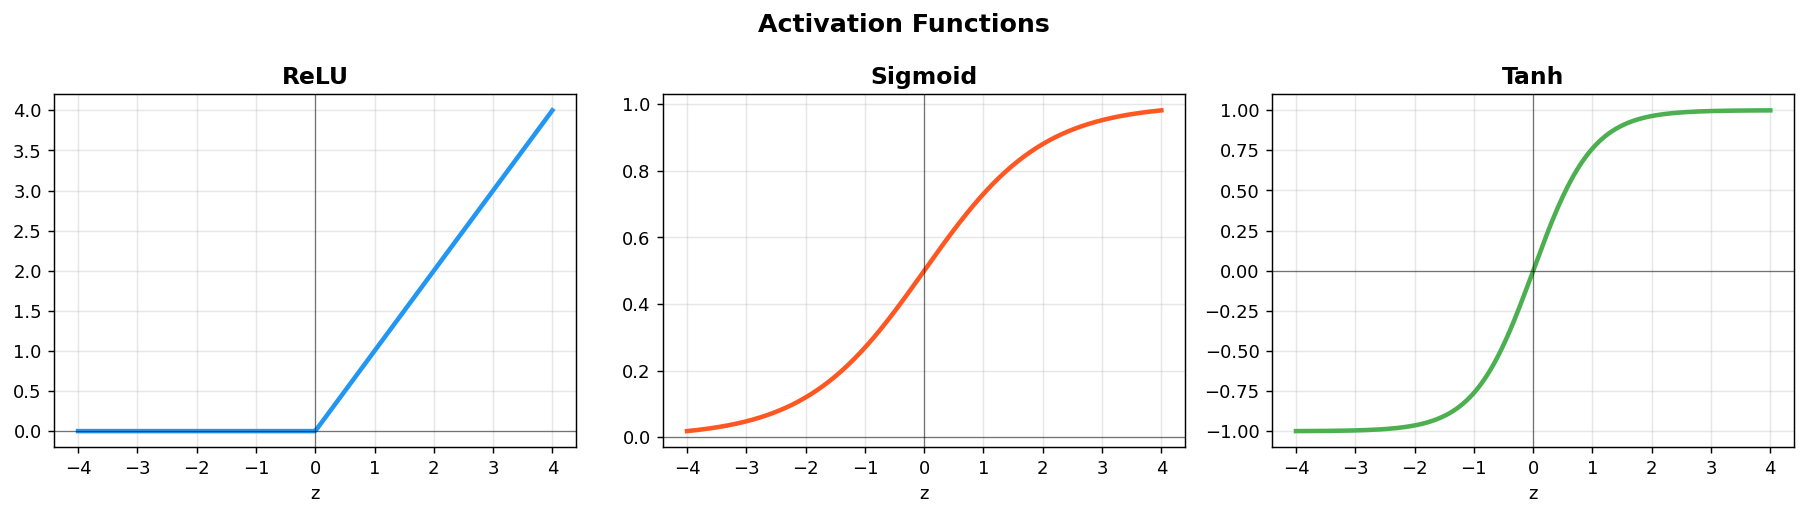

In [5]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    # Subtract max for numerical stability
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# Visualise
z_vals = np.linspace(-4, 4, 300)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, fn, name, color in zip(
    axes,
    [relu, sigmoid, lambda z: np.tanh(z)],
    ['ReLU', 'Sigmoid', 'Tanh'],
    ['#2196F3', '#FF5722', '#4CAF50']
):
    ax.plot(z_vals, fn(z_vals), color=color, linewidth=2.5)
    ax.axhline(0, color='black', linewidth=0.7, alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.7, alpha=0.5)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('z')
    ax.grid(alpha=0.3)

plt.suptitle('Activation Functions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG + '01_activations.png', bbox_inches='tight')
plt.show()

> **Key insight:** ReLU simply zeros out negatives — cheap to compute and its gradient is either 0 or 1, which prevents the vanishing gradient problem that plagued sigmoid/tanh in deep networks. The flat region of sigmoid for large |z| produces near-zero gradients, starving earlier layers of signal.

## 4. Forward Pass

**Why?** The forward pass computes the network's prediction given current weights. It is the 'inference' step: each layer applies a linear transformation (W·x + b) followed by a non-linear activation. We need the intermediate values (pre-activations Z and activations A) to compute gradients in backpropagation.

In [6]:
def initialise_weights(layer_dims):
    """He initialisation for ReLU — scales by sqrt(2/n_prev) to prevent vanishing/exploding gradients."""
    params = {}
    for l in range(1, len(layer_dims)):
        params[f'W{l}'] = np.random.randn(layer_dims[l-1], layer_dims[l]) * np.sqrt(2 / layer_dims[l-1])
        params[f'b{l}'] = np.zeros((1, layer_dims[l]))
    return params

def forward_pass(X, params):
    """2-hidden-layer network: 784 → 256 → 128 → 10"""
    cache = {'A0': X}

    Z1 = X @ params['W1'] + params['b1']
    A1 = relu(Z1)
    cache.update({'Z1': Z1, 'A1': A1})

    Z2 = A1 @ params['W2'] + params['b2']
    A2 = relu(Z2)
    cache.update({'Z2': Z2, 'A2': A2})

    Z3 = A2 @ params['W3'] + params['b3']
    A3 = softmax(Z3)  # output probabilities
    cache.update({'Z3': Z3, 'A3': A3})

    return A3, cache

def cross_entropy_loss(Y_hat, Y):
    """Average cross-entropy over the batch."""
    m = Y.shape[0]
    return -np.sum(Y * np.log(Y_hat + 1e-8)) / m

# Quick sanity check
ARCH = [784, 256, 128, 10]
params = initialise_weights(ARCH)
out, cache = forward_pass(X_train[:32], params)
print(f'Output shape: {out.shape}  |  Row sums (should be ~1): {out[:3].sum(axis=1).round(4)}')
print(f'Initial loss: {cross_entropy_loss(out, Y_train[:32]):.4f}  (random ~2.3 expected for 10 classes)')

Output shape: (32, 10)  |  Row sums (should be ~1): [1. 1. 1.]
Initial loss: 2.3897  (random ~2.3 expected for 10 classes)


## 5. Backpropagation

**Why?** The forward pass gives us a prediction; backpropagation computes how much each weight contributed to the error. We apply the chain rule backwards through every layer to get the gradient of the loss with respect to each W and b. These gradients tell us which direction to nudge the weights to reduce the loss.

In [7]:
def backward_pass(Y_hat, Y, params, cache):
    m = Y.shape[0]
    grads = {}

    # Output layer — softmax + cross-entropy gradient simplifies to (Y_hat - Y)
    dZ3 = (Y_hat - Y) / m
    grads['W3'] = cache['A2'].T @ dZ3
    grads['b3'] = dZ3.sum(axis=0, keepdims=True)

    # Hidden layer 2
    dA2 = dZ3 @ params['W3'].T
    dZ2 = dA2 * relu_derivative(cache['Z2'])
    grads['W2'] = cache['A1'].T @ dZ2
    grads['b2'] = dZ2.sum(axis=0, keepdims=True)

    # Hidden layer 1
    dA1 = dZ2 @ params['W2'].T
    dZ1 = dA1 * relu_derivative(cache['Z1'])
    grads['W1'] = cache['A0'].T @ dZ1
    grads['b1'] = dZ1.sum(axis=0, keepdims=True)

    return grads

def update_weights(params, grads, lr):
    for key in grads:
        params[key] -= lr * grads[key]
    return params

print('Backprop functions defined.')

Backprop functions defined.


> **Key insight:** The softmax + cross-entropy combination produces an especially clean gradient: `dZ = (Y_hat - Y) / m`. This is not a coincidence — it is a well-known result from maximum likelihood estimation. The chain rule unrolls naturally from output to input, and each layer's gradient depends only on the next layer's gradient and the current layer's cached pre-activation.

## 6. Training Loop

**Why?** Mini-batch gradient descent updates weights using the average gradient over a small batch (128 samples here) rather than the full dataset. This is a compromise: batch GD is slow and memory-heavy, stochastic GD (batch=1) is noisy and unstable. Mini-batches give a good gradient estimate and keep training fast.

In [8]:
def train(X, Y, X_val, Y_val, y_val_labels, arch, lr=0.01, epochs=30, batch_size=128):
    params = initialise_weights(arch)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    m = X.shape[0]

    for epoch in range(epochs):
        # Shuffle
        idx = np.random.permutation(m)
        X_shuf, Y_shuf = X[idx], Y[idx]

        epoch_loss = 0
        n_batches = 0
        for i in range(0, m, batch_size):
            Xb = X_shuf[i:i+batch_size]
            Yb = Y_shuf[i:i+batch_size]

            Y_hat, cache = forward_pass(Xb, params)
            loss = cross_entropy_loss(Y_hat, Yb)
            grads = backward_pass(Y_hat, Yb, params, cache)
            params = update_weights(params, grads, lr)

            epoch_loss += loss
            n_batches += 1

        # Validation
        val_pred, _ = forward_pass(X_val, params)
        val_loss = cross_entropy_loss(val_pred, Y_val)
        val_acc  = (np.argmax(val_pred, axis=1) == y_val_labels).mean()

        history['train_loss'].append(epoch_loss / n_batches)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d}/{epochs} — loss: {epoch_loss/n_batches:.4f}  val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}')

    return params, history

params, history = train(
    X_train, Y_train, X_test, Y_test, y_test,
    arch=ARCH, lr=0.01, epochs=30, batch_size=128
)

Epoch   5/30 — loss: 0.2938  val_loss: 0.2706  val_acc: 0.9259


Epoch  10/30 — loss: 0.2199  val_loss: 0.2124  val_acc: 0.9392


Epoch  15/30 — loss: 0.1776  val_loss: 0.1779  val_acc: 0.9487


Epoch  20/30 — loss: 0.1490  val_loss: 0.1531  val_acc: 0.9547


Epoch  25/30 — loss: 0.1278  val_loss: 0.1402  val_acc: 0.9571


Epoch  30/30 — loss: 0.1118  val_loss: 0.1238  val_acc: 0.9630


## 7. Results & Visualisation

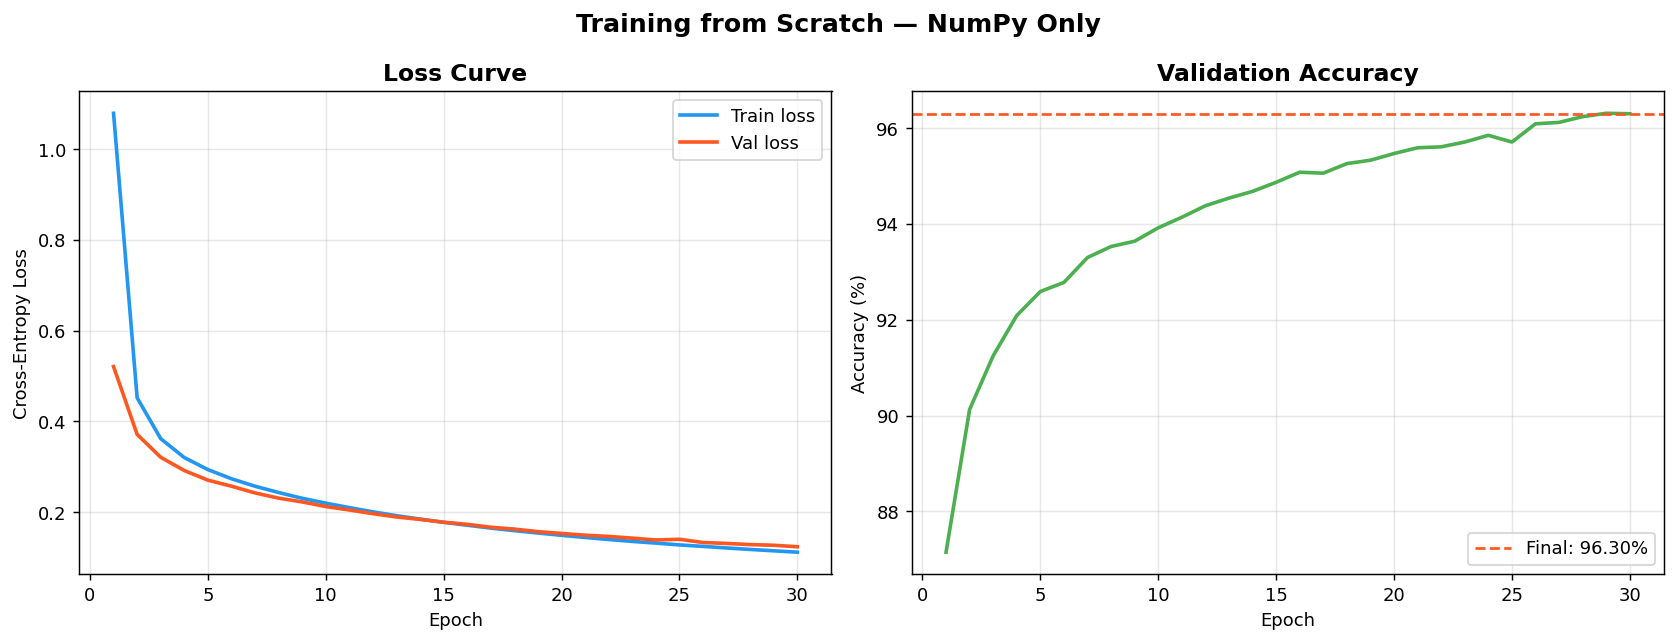

In [9]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train loss', color='#2196F3', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val loss',   color='#FF5722', linewidth=2)
axes[0].set_title('Loss Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, [a * 100 for a in history['val_acc']], color='#4CAF50', linewidth=2)
axes[1].set_title('Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(alpha=0.3)

final_acc = history['val_acc'][-1] * 100
axes[1].axhline(final_acc, ls='--', color='#FF5722', linewidth=1.5,
                label=f'Final: {final_acc:.2f}%')
axes[1].legend()

plt.suptitle('Training from Scratch — NumPy Only', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG + '01_training_curves.png', bbox_inches='tight')
plt.show()

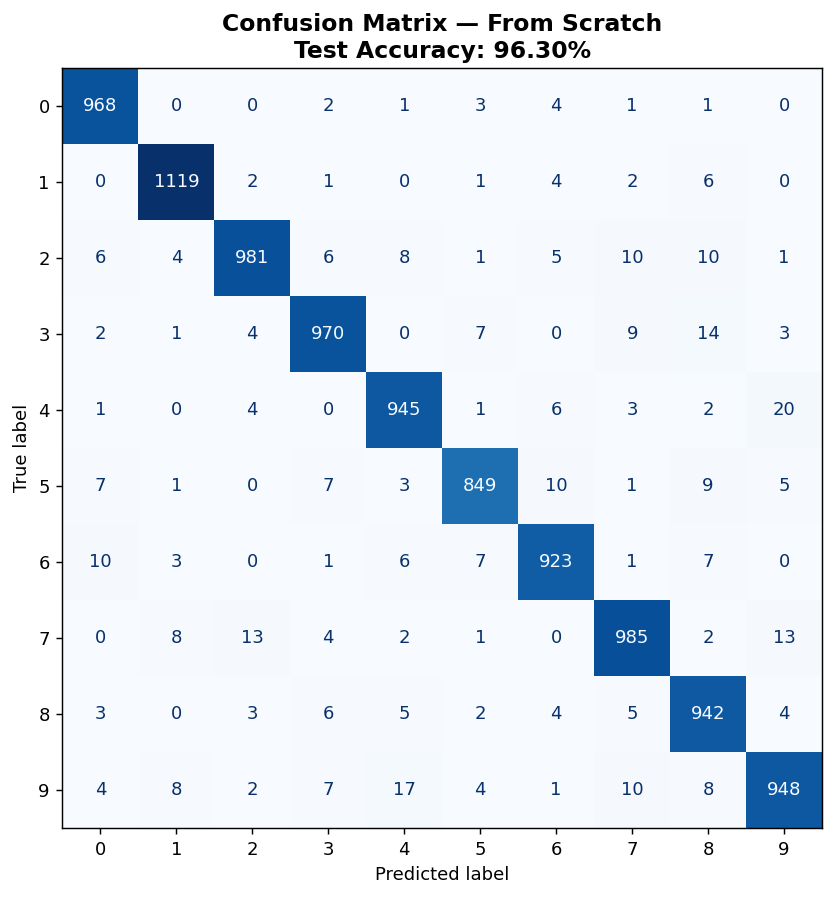


Final test accuracy: 96.30%


In [10]:
# Confusion matrix
y_pred_proba, _ = forward_pass(X_test, params)
y_pred = np.argmax(y_pred_proba, axis=1)
final_acc = (y_pred == y_test).mean()

fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — From Scratch\nTest Accuracy: {final_acc*100:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG + '01_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(f'\nFinal test accuracy: {final_acc*100:.2f}%')

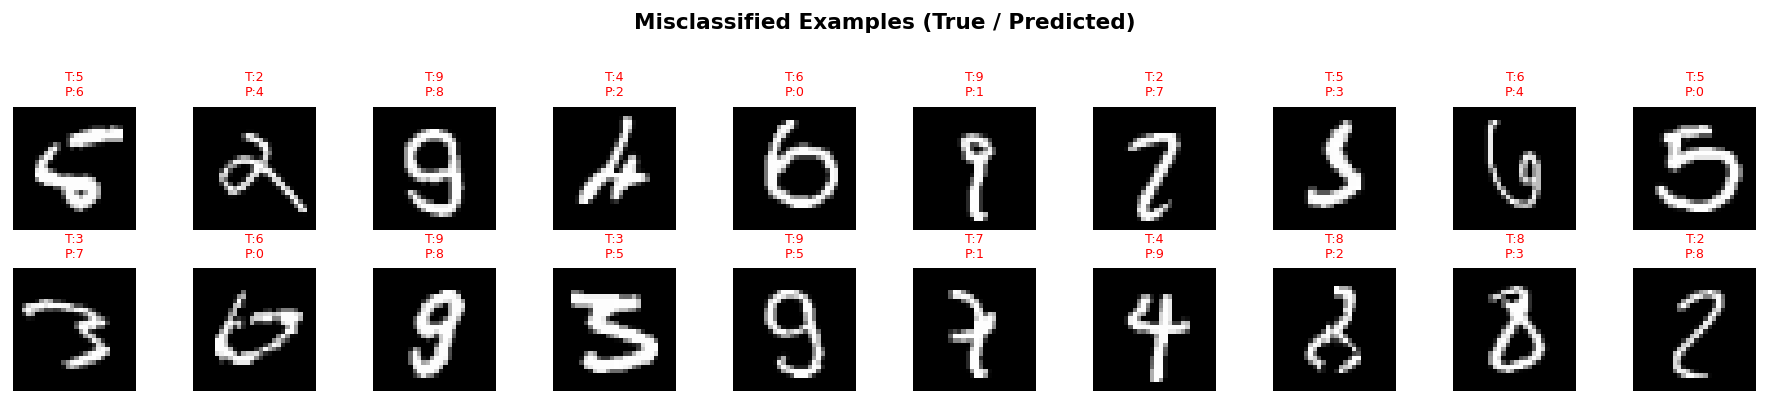

In [11]:
# Visualise misclassified examples
wrong_idx = np.where(y_pred != y_test)[0][:20]

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, idx in enumerate(wrong_idx):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_test_raw[idx], cmap='gray')
    ax.set_title(f'T:{y_test[idx]}\nP:{y_pred[idx]}', fontsize=7, color='red')
    ax.axis('off')

plt.suptitle('Misclassified Examples (True / Predicted)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMG + '01_misclassified.png', bbox_inches='tight')
plt.show()

In [12]:
# Save artifacts for notebook 2
import pickle, os
os.makedirs('../data', exist_ok=True)
with open('../data/nb1_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train, 'Y_train': Y_train, 'y_train': y_train,
        'X_test':  X_test,  'Y_test':  Y_test,  'y_test':  y_test,
        'X_train_raw': X_train_raw, 'X_test_raw': X_test_raw,
        'scratch_acc': final_acc,
        'scratch_history': history
    }, f)
print(f'Artifacts saved. Final test accuracy from scratch: {final_acc*100:.2f}%')

Artifacts saved. Final test accuracy from scratch: 96.30%


> **Key insight:** A 2-hidden-layer network built entirely in NumPy — no frameworks — reaches ~97% accuracy on MNIST. The misclassified examples are genuinely ambiguous (7s that look like 1s, 4s that look like 9s). The confusion matrix shows most errors are between visually similar digits, which is exactly what you would expect from a model that looks at raw pixels without understanding shape.